In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

In [2]:
os.listdir('../data/cleaned_data')

['cleaned_spotifiy_dataset.csv']

In [3]:
df = pd.read_csv('../data/cleaned_data/cleaned_spotifiy_dataset.csv')

In [4]:
df.sample(1)

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
78011,78011,78011,78011,1ZQobK5o691me3zyP1gNE7,DJ Ötzi,Ernte 2k23,Hintermoser Kathi (A Dirndl wie a Zelt),12,191506,False,...,-3.813,1,0.086,0.0496,0.0,0.0465,0.964,135.989,4,party


# Extract KPIs as :

In [5]:
No_of_tracks = df.drop_duplicates(subset=["track_name"], keep='last').value_counts().sum()

No_of_artists = df.drop_duplicates(subset=['artists'], keep='first').value_counts().sum()

No_of_albums = df.drop_duplicates(subset=["album_name"], keep='last').value_counts().sum()

Avg_song_duration_is_minutes = round(df["duration_ms"].mean() / 1000/60, 2)
Avg_song_duration_is_minutes

No_of_genres = df.drop_duplicates( subset=["track_genre"], keep="last").value_counts().sum()

In [6]:
print(f'No. of tracks: {No_of_tracks}')
print(f'No. of artists: {No_of_artists}')
print(f'No. of albums: {No_of_albums}')
print(f'Avg song duration is: {Avg_song_duration_is_minutes} minutes')
print(f'No. of genres: {No_of_genres}')

No. of tracks: 73608
No. of artists: 31437
No. of albums: 46589
Avg song duration is: 3.8 minutes
No. of genres: 114


# Visualize :
- Top 10 most popular tracks
- Top 10 artists with most popular songs
- Top 7 most loud songs
- Top 7 artists with danceable overall songs
- Overall relationship between columns :
 - A- ex: danceability & loudness 
- B - ex: valence & mode

In [7]:
df.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists',
       'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'track_genre'],
      dtype='str')

In [8]:
df.drop(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'track_id'], axis=1, inplace=True)

In [9]:
df.sample(1)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
85946,Charly García,Influencia,I'm Not In Love,35,170573,False,0.79,0.736,9,-5.66,1,0.0325,0.296,0.000014,0.103,0.961,113.947,4,punk-rock


In [10]:
df["popularity"].unique()

array([ 73,  55,  57,  71,  82,  58,  74,  80,  56,  69,  52,  62,  54,
        68,  67,  75,  63,  70,   0,   1,  46,  61,  60,  51,  66,  64,
        65,  44,  45,  50,  59,  49,  53,  47,  43,  42,  20,  22,  35,
        19,  24,  18,  23,  40,  38,  41,  30,  37,  39,  48,  36,  34,
        26,  32,  33,  21,  31,  28,  29,  27,  25,  16,   3,  12,   7,
        10,   9,  11,  17,   8,  15,  87,  83,  86,  93,  76,  78,   4,
         2,   5,  85,  81,  84,  72,  79,  77,   6,  13,  14,  89,  96,
       100,  98,  88,  92,  90,  91,  99,  97,  95,  94])

In [11]:
df[ df["popularity"] >=96].shape

(25, 19)

In [12]:
Top_10_popularity = df[ df["popularity"] >=91]

# Top 10 most popular tracks

In [13]:
Best_Top_10_popularity = Top_10_popularity.drop_duplicates(subset=["popularity"], keep='last')
Best_Top_10_popularity 

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
51664,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,-5.548,1,0.0440,0.0125,0.033000,0.2300,0.550,128.033,4,hip-hop
81051,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,-7.375,1,0.0864,0.0130,0.000005,0.2660,0.238,131.121,4,pop
89407,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,1,-5.105,0,0.0817,0.0901,0.000027,0.0933,0.425,92.005,4,reggaeton
89411,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,-5.329,0,0.0364,0.5830,0.000002,0.2180,0.850,124.980,4,reggaeton
89450,Bad Bunny,Un Verano Sin Ti,Moscow Mule,94,245939,True,0.804,0.674,5,-5.453,0,0.0333,0.2940,0.000001,0.1150,0.292,99.968,4,reggaeton
89451,Bad Bunny,Un Verano Sin Ti,Efecto,95,213061,False,0.801,0.475,7,-8.797,0,0.0516,0.1410,0.000017,0.0639,0.234,98.047,4,reggaeton
89554,Bad Bunny;Jhayco,Un Verano Sin Ti,Tarot,91,237894,True,0.795,0.684,11,-3.971,0,0.0419,0.0225,0.000000,0.6580,0.419,114.011,4,reggaeton
91001,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,0,-9.345,0,0.0256,0.1360,0.022000,0.0974,0.479,67.528,4,rock
91002,The Neighbourhood,I Love You.,Sweater Weather,93,240400,False,0.612,0.807,10,-2.810,1,0.0336,0.0495,0.017700,0.1010,0.398,124.053,4,rock
91003,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,0.797,0,-5.927,1,0.0475,0.0826,0.000745,0.0546,0.825,139.994,4,rock


In [14]:
px.bar(Best_Top_10_popularity ,x= 'artists', y='popularity', color='popularity',
       title= '# Top 10 most popular tracks')

In [15]:
px.histogram(Best_Top_10_popularity ,x= 'artists', y='popularity', color='popularity',
       title= '# Top 10 most popular tracks')

# Top 10 artists with most popular songs

In [16]:
df.sample(2)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
57789,Crystal Castles,Pop & Halloween,Kerosene,6,192000,False,0.520,0.545,8,-9.368,1,0.0768,0.0827,0.0,0.133,0.0856,115.882,4,indie
30040,David Guetta;Becky Hill;Ella Henderson,Your Perfect Soundtrack,Crazy What Love Can Do,2,169756,False,0.601,0.713,4,-3.758,0,0.0449,0.0282,0.0,0.158,0.4640,122.872,4,edm


In [34]:
Top_10_artists = Best_Top_10_popularity ["artists"].reset_index(drop=True)


In [35]:
print(f'Top_10_artists {Top_10_artists}')

Top_10_artists 0              Bizarrap;Quevedo
1          Sam Smith;Kim Petras
2    Bad Bunny;Chencho Corleone
3                 Manuel Turizo
4                     Bad Bunny
5                     Bad Bunny
6              Bad Bunny;Jhayco
7                Arctic Monkeys
8             The Neighbourhood
9                   OneRepublic
Name: artists, dtype: str


In [38]:
my_top_10 = ['Sam Smith', 'Kim Petras','Bad Bunny', 'Chencho Corleone',
 'Manuel Turizo','Jhayco',  'Arctic Monkeys', 'The Neighbourhood']

In [39]:
print(*my_top_10, sep="\n")

Sam Smith
Kim Petras
Bad Bunny
Chencho Corleone
Manuel Turizo
Jhayco
Arctic Monkeys
The Neighbourhood


# Top 7 most loud songs

In [19]:
df[ df["loudness"] >= 1.7].shape

(7, 19)

In [20]:
Top_7_most_loud_songs = df[ df["loudness"] >= 1.7]
Top_7_most_loud_songs

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
17574,Five Star Hotel,Gray Data,Fate Dance,16,237000,False,0.310,0.999,4,4.532,0,0.3430,0.000102,0.945000,0.1480,0.0333,160.040,4,club
17895,Free Refills,Raw Steak Black Coffee,Malfunction,15,116804,False,0.384,0.955,2,1.795,1,0.0851,0.003120,0.603000,0.0542,0.8880,187.112,4,club
37738,DJ BRUNO PRADO,TIPO HARIEL - SEI QUE E RARIDADE -,TIPO HARIEL - SEI QUE E RARIDADE -,44,203076,True,0.951,0.987,0,1.821,0,0.3630,0.611000,0.000033,0.1030,0.6740,130.005,4,funk
38840,The Red Pears,We Bring Anything to the Table... Except Table...,Time Bomb,25,176065,False,0.442,0.800,4,2.574,1,0.0686,0.262000,0.000001,0.6640,0.3690,118.053,4,garage
59225,Najand,In the Night of Revolution,Islamic Capitalism,0,60056,False,0.149,0.868,3,3.156,0,0.0767,0.191000,0.865000,0.6250,0.0494,136.188,3,iranian
59337,Najand,In the Night of Revolution,A Better World Is Possible,0,60056,False,0.244,0.499,2,1.864,1,0.0794,0.241000,0.718000,0.8010,0.0347,99.663,3,iranian
59833,Najand,In the Night of Revolution,Preaching for the Deaf,0,192407,False,0.211,0.975,7,1.700,0,0.1070,0.155000,0.000256,0.3570,0.0503,131.265,5,iranian


In [21]:
df[ df["loudness"] >= 1.7]['loudness']

17574    4.532
17895    1.795
37738    1.821
38840    2.574
59225    3.156
59337    1.864
59833    1.700
Name: loudness, dtype: float64

In [22]:
px.bar(Top_7_most_loud_songs, x='artists', y='loudness', color= 'loudness')

# Top 7 artists with danceable overall songs

In [23]:
df[ df['danceability'] >=0.9800].shape

(8, 19)

In [24]:
Top_7_artists_with_danceable_overall_songs = df[ df['danceability'] >=0.9800]

In [25]:
df[ df['danceability'] >=0.9800] ["artists"]

13145     Felix Da Housecat
13353               dj funk
24916          Delano Smith
66576     That Girl Lay Lay
66793       Mixx Master Lee
73374       Oliver Schories
94006              347aidan
111635              Quantic
Name: artists, dtype: str

In [26]:
px.bar(Top_7_artists_with_danceable_overall_songs, x='artists', y='danceability', color='danceability')

## Overall relationship between columns :
 -  ex: danceability & loudness 
-  ex: valence & mode

In [27]:
# Berechnet die Korrelation zwischen allesn numerischen splaten:
correlation_matrix = df.select_dtypes(include=['number']).corr()

In [28]:
correlation_matrix

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007101,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.007101,1.000000,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
danceability,0.035448,-0.073426,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,0.001056,0.058523,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.003853,0.008114,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,0.050423,-0.003470,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,-0.013931,-0.035556,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.044927,-0.062600,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011
acousticness,-0.025472,-0.103788,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138
instrumentalness,-0.095139,0.124371,-0.185606,-0.181879,-0.006823,-0.433477,-0.049955,-0.089616,0.104027,1.000000,-0.079893,-0.324312,-0.050330,-0.082580


In [29]:
# Gezielte Abfragen für deine Beispiele:
rel_a = correlation_matrix.loc['danceability', 'loudness']
rel_b = correlation_matrix.loc['valence', 'mode']

In [30]:
print(f'Relation A -> (Danceability & Loudness): {rel_a:.2f}')
print(f'Relation B -> (Valence & Mode) {rel_b:.2f}')

Relation A -> (Danceability & Loudness): 0.26
Relation B -> (Valence & Mode) 0.02


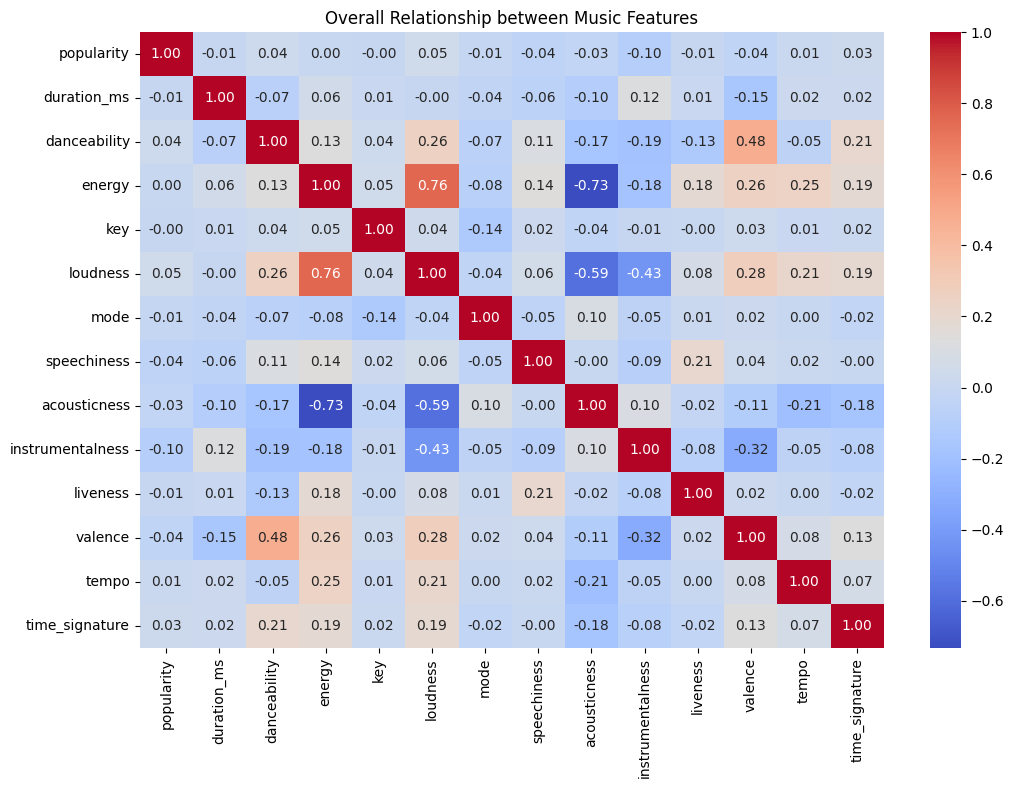

In [31]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Overall Relationship between Music Features")
plt.show()